In [146]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 


In [147]:
# ls binaural_eval/precedence_distractor_test_v02/

In [148]:
# Path to results 
# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations
# match human pilot conditions
# model_name = 'word_task_half_co_loc_v06'
output_paths = list(Path(f"binaural_eval/precedence_distractor_test_v02/").glob("*/*v10*.pkl"))
# output_paths = list(Path(f"ls /om2/user/rphess/Auditory-Attention/binaural_eval/precedence_distractor_test/").glob("*/*.pkl"))

stim_manifest_df = pd.read_pickle('/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl')

remap_azim = lambda azim: 360 - azim if azim > 90 else 0 - azim 

results_dfs = []

gend_map = {True:'same', False:'diff'}

for path in output_paths:
    if 'v10' not in path.stem:
        continue
    # if any([string in path.stem for string in ['v06', 'more', 'old']]):
    #     continue
    res_dict = pickle.load(open(path, 'rb'))
    df = pd.DataFrame.from_dict(res_dict)
    df.rename(columns={"results": "accuracy"}, inplace=True)
    df['model'] = path.parent.stem
    # merge with stim manifest
    df = df.join(stim_manifest_df[['word', 'bg_word','gender', 'bg_gender']], how='outer')  
    diotic =  True if 'diotic' in path.stem else False 
    df['diotic'] = diotic
    df['diotic_cond'] = None
    if 'clean' in path.stem:
        snr = 'clean'
    else:
        snr = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
    df['snr'] = snr 
    if diotic:
        target_loc = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')[0]
        df["target_azim"], df["target_elev"] = target_loc, target_loc
        distractor_loc = path.stem.split('_distract_loc_')[1].split('_')[0] 
        df["distractor_azim"], df["distractor_elev"] = distractor_loc, distractor_loc
        if snr == 'clean':
            df['diotic_cond'] = 'clean'
        else:
            df['diotic_cond'] = 'overlap' if target_loc == distractor_loc else distractor_loc
        df['dist_lead_channel'] = distractor_loc

    else:
        df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
        df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')[:2]
        # map azim to 0-180
        df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
        df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
        df['target_elev'] = df['target_elev'].astype(int)
        df['distractor_elev'] = df['distractor_elev'].astype(int)
        lead_channel = path.stem.split('_lead_')[0].split('_')[-1]
        if lead_channel == 'None':
            if (df['target_azim'].values == df['distractor_azim'].values).all():
                lead_channel = 'F-F'
            elif (df['target_azim'].values != df['distractor_azim'].values).all():
                lead_channel = 'F-R'
        else:
            if 'target_lead' in path.stem:
                # print('both simulated')
                if lead_channel == 'center':
                    lead_channel = 'FR-FR'
                elif lead_channel == 'side':
                    lead_channel = 'FR-RF'
            else:
                if lead_channel == 'center':
                    lead_channel = 'F-FR'
                elif lead_channel == 'side':
                    lead_channel = 'F-RF'
    
        df['dist_lead_channel'] = lead_channel

        
    df['gender_cond'] = df["gender"].values == df['bg_gender'].values
    df['gender_cond'] =  df['gender_cond'].map(gend_map)
    if 'clean' in path.stem:
        df['snr'] = 'clean'
    else:
        df['snr'] = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
    
    results_dfs.append(df)
results = pd.concat(results_dfs)

In [149]:
# results.loc[(results.distractor_azim != 0) & (results.dist_lead_channel == "F-F")] = results[results.dist_lead_channel == "F-F"] 

In [150]:
# results[results.model == 'word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout']

In [151]:
grouped_results = results.groupby(['model', 'target_azim', 'target_elev', 'distractor_azim','dist_lead_channel', 'diotic',
                                 'distractor_elev', 'gender_cond', 'snr']).agg({'accuracy':['mean', 'sem'],
                                                                                                                     'confusions':['mean', 'sem']}).reset_index()
# flatten multiindex
grouped_results.columns = ['_'.join(col).strip() for col in grouped_results.columns.values]
# remove trailing underscore
grouped_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_results.columns.values]


# # grouped_results["elevation_cond"] = grouped_results.apply(lambda row: f"target {row.target_elev} distractor {row.distractor_elev}", axis=1)
# grouped_results['elevation_sep'] = grouped_results.target_elev - grouped_results.distractor_elev
# grouped_results['abs_elevation_sep'] = grouped_results.elevation_sep.abs()
# grouped_results['elevated_source'] = grouped_results.elevation_sep.apply(lambda x: 'target' if x > 0 else 'distractor' if x < 0 else 'co-located') 

# grouped_results['abs_target_azim'] = grouped_results.target_azim.abs()
# grouped_results['abs_distractor_azim'] = grouped_results.distractor_azim.abs()

# grouped_results['azim_delta'] = grouped_results.target_azim - grouped_results.distractor_azim
# grouped_results['abs_azim_delta'] = (grouped_results.target_azim - grouped_results.distractor_azim).abs()




In [152]:
grouped_results.model.value_counts()

model
word_task_early_only_v10                  48
word_task_v10_4MGB_ln_first_arch_6        48
word_task_v10_4MGB_ln_first_arch_7        48
word_task_v10_control_no_attn             48
word_task_late_only_v10                   46
word_task_v10_4MGB_ln_first_arch_8        46
word_task_v10_4MGB_ln_first_arch_10       44
word_task_v10_4MGB_ln_first_arch_4        44
word_task_v10_4MGB_ln_first_arch_2        42
word_task_v10_main_feature_gain_config    42
word_task_v10_4MGB_ln_first_arch_12       40
word_task_v10_4MGB_ln_first_arch_1        38
word_task_v10_4MGB_ln_first_arch_9        36
Name: count, dtype: int64

In [153]:
grouped_results

,model,target_azim,target_elev,distractor_azim,dist_lead_channel,diotic,distractor_elev,gender_cond,snr,accuracy_mean,accuracy_sem,confusions_mean,confusions_sem
0,word_task_early_only_v10,0,0,-60,FR-FR,False,0,diff,-12,0.108999,0.007848,0.489227,0.012588
1,word_task_early_only_v10,0,0,-60,FR-FR,False,0,diff,-8,0.179341,0.009661,0.391635,0.012292
2,word_task_early_only_v10,0,0,-60,FR-FR,False,0,diff,-4,0.278200,0.011284,0.279468,0.011300
3,word_task_early_only_v10,0,0,-60,FR-FR,False,0,diff,0,0.387199,0.012266,0.183777,0.009753
4,word_task_early_only_v10,0,0,-60,FR-FR,False,0,same,-12,0.090621,0.007229,0.529151,0.012569
...,...,...,...,...,...,...,...,...,...,...,...,...,...
565,word_task_v10_main_feature_gain_config,0,0,60,F-R,False,0,same,0,0.806084,0.009956,0.001267,0.000896
566,word_task_v10_main_feature_gain_config,0,0,60,F-RF,False,0,diff,-12,0.421420,0.012434,0.103295,0.007664
567,word_task_v10_main_feature_gain_config,0,0,60,F-RF,False,0,diff,0,0.719899,0.011308,0.011407,0.002674
568,word_task_v10_main_feature_gain_config,0,0,60,F-RF,False,0,same,-12,0.347909,0.011994,0.223067,0.010483


In [154]:
freyman_human_data = np.array([-11.937626695774213,73.05785123966942,
                            -7.8768127241540675,85.2892561983471,
                            -3.8259784812100452,92.23140495867769,
                            0.17838765008576019,94.54545454545455,
                            -11.99844066739436,40.826446280991746,
                            -7.911429907999382,66.94214876033058,
                            -3.8920941836893856,77.19008264462809,
                            0.09168875721191228,88.59504132231405,
                            -11.95696242008421,42.80991735537191,
                            -7.883050054576644,61.98347107438017,
                            -3.933884297520663,75.04132231404958,
                            0.15874005925463663,84.13223140495867,
                            -12.006237330422584,36.69421487603306,
                            -7.984406673943557,48.26446280991736,
                            -3.9828473413379104,49.0909090909091,
                            0.08794635895836223,66.61157024793388]).reshape(-1,2)

freyman_human_data = pd.DataFrame({'snr':freyman_human_data[:,0], 'accuracy':freyman_human_data[:,1]})
freyman_human_data['diotic_cond'] = ["F-R"] * 4 + ["F-RF"] * 4 + ["F-FR"] * 4 + ["F-F"] * 4
freyman_human_data

,snr,accuracy,diotic_cond
0,-11.937627,73.057851,F-R
1,-7.876813,85.289256,F-R
2,-3.825978,92.231405,F-R
3,0.178388,94.545455,F-R
4,-11.998441,40.826446,F-RF
5,-7.911430,66.942149,F-RF
6,-3.892094,77.190083,F-RF
7,0.091689,88.595041,F-RF
8,-11.956962,42.809917,F-FR
9,-7.883050,61.983471,F-FR


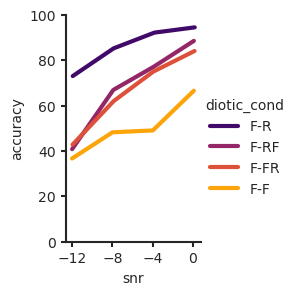

In [155]:

g = sns.relplot(data=freyman_human_data, x='snr', y='accuracy', 
            hue='diotic_cond', kind='line', palette='inferno',
            height=3, linewidth=3, aspect=0.75)
g.set(yticks=np.arange(0,  101, 20), xticks=np.arange(-12,  1, 4))
# thicken axis lines
for axis in ['bottom','left']:
    g.ax.spines[axis].set_linewidth(1.5)
# match x and y tick thickness to axes lines
g.ax.tick_params(width=1.5)

### MAKE Poster fig 

In [156]:
freyman_grouped_results = results[results.diotic == False].groupby(['model', 'target_azim', 'distractor_azim', 'dist_lead_channel', 'gender_cond',  'snr']).agg({'accuracy':['mean', 'sem'], 'confusions':['mean', 'sem']}).reset_index()
# flatten multiindex
freyman_grouped_results.columns = ['_'.join(col).strip() for col in freyman_grouped_results.columns.values]
# remove trailing underscore
freyman_grouped_results.columns = [col[:-1] if col[-1] == '_' else col for col in freyman_grouped_results.columns.values]


In [157]:
freyman_grouped_results.model.unique()

array(['word_task_early_only_v10', 'word_task_late_only_v10',
       'word_task_v10_4MGB_ln_first_arch_1',
       'word_task_v10_4MGB_ln_first_arch_10',
       'word_task_v10_4MGB_ln_first_arch_12',
       'word_task_v10_4MGB_ln_first_arch_2',
       'word_task_v10_4MGB_ln_first_arch_4',
       'word_task_v10_4MGB_ln_first_arch_6',
       'word_task_v10_4MGB_ln_first_arch_7',
       'word_task_v10_4MGB_ln_first_arch_8',
       'word_task_v10_4MGB_ln_first_arch_9',
       'word_task_v10_control_no_attn',
       'word_task_v10_main_feature_gain_config'], dtype=object)

In [158]:
# freyman_grouped_results[(freyman_grouped_results.model == 'word_task_standard_v07')].distractor_azim.unique()

In [159]:
# to_plot[to_plot.diotic_cond == 'overlap']

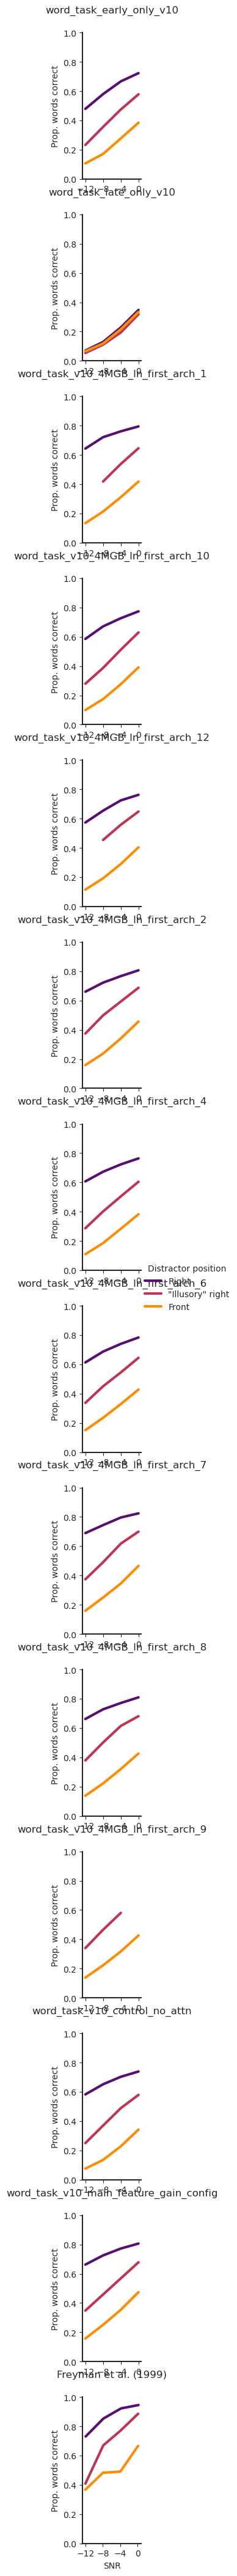

In [160]:
# hue_order = ['F-R', "F-FR", "F-RF", "FR-RF", "FR-FR", 'F-F']
hue_order = ['F-R', "F-RF", 'F-F']

# rename dist_lead_channel names 
name_map = {'F-R':'Right', 'F-FR':'Sim. Front', 'F-RF':'"Illusory" right', 'F-F':'Front', 'FR-RF':'Both simulated, right distractor', 'FR-FR':'Both simulated front'}
hue_order = [name_map[x] for x in hue_order]




sns.set_style('ticks')

# models_to_plot = ['word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout', 'word_task_v09_control_no_attn']

# model_name_dict = {'word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout' : 'Feature-gain Model', 'word_task_v09_control_no_attn': 'Baseline Model'}

model_to_plot = freyman_grouped_results[freyman_grouped_results.gender_cond == 'same'].copy() # freyman_grouped_results[(freyman_grouped_results.model == 'word_task_standard_v07')].copy()
# model_to_plot = freyman_grouped_results[freyman_grouped_results.model.isin(models_to_plot)].copy()
model_to_plot.loc[model_to_plot.distractor_azim == 0, "distractor_azim"] = 60
# make dist location be abs 
model_to_plot['distractor_azim'] = model_to_plot['distractor_azim'].abs()

model_to_plot.loc[model_to_plot.snr == 'clean', 'snr'] = 6
model_to_plot = model_to_plot[(model_to_plot.snr.isin([-12, -8, -4, 0])) & (model_to_plot.distractor_azim == 60)]
# model_to_plot['model'] = model_to_plot['model'].map(model_name_dict).values
# model_to_plot['model'] = 'Model'

# merge model_to_plot with human data
freyman_human_data['model'] = 'Freyman et al. (1999)'
freyman_human_data['dist_lead_channel'] = freyman_human_data['diotic_cond'] 
freyman_human_data['accuracy_mean'] = freyman_human_data['accuracy']/100

data_to_plot = pd.concat([model_to_plot, freyman_human_data], axis=0)

data_to_plot['dist_lead_channel'] = data_to_plot['dist_lead_channel'].map(name_map)


g = sns.relplot(data=data_to_plot, x='snr', y='accuracy_mean',
             col='model', col_wrap=1, #col_order=['Freyman et al. (1999)'] + list(model_name_dict.values()),
            hue='dist_lead_channel', kind='line',# row='gender_cond',
            palette='inferno',hue_order=hue_order,
            height=3, linewidth=3, aspect=0.75, legend=True,
            facet_kws={'sharey': False, 'sharex': False}
)

g.set(yticks=np.arange(0,  1.1, .20), xticks=np.arange(-12,  1, 4))
# set titles
# g.set_titles("{col_name} {row_name}", size=12, y=1.1)
g.set_titles("{col_name}", size=12, y=1.1)
# set axis labels
g.set_axis_labels("SNR", "Prop. words correct")
# set legend title
g._legend.set_title("Distractor position")
# add w space
g.fig.subplots_adjust(wspace=.4)

# add x and y ticks 


# move legend closer to plot
# g._legend.set_bbox_to_anchor([0.9, 0.5])
# thicken axis lines
for ax in g.axes.flat:
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)
# don't share y ticks
# plt.tight_layout()
# outfig_dest = Path('ARO_2024/figures')
# plt.tight_layout()
# plt.savefig(outfig_dest/'freyman_plot.svg', transparent=True, bbox_inches='tight')

In [127]:
# fba_models

In [128]:
freyman_human_data

,snr,accuracy,diotic_cond,model,dist_lead_channel,accuracy_mean
0,-11.937627,73.057851,F-R,Freyman et al. (1999),F-R,0.730579
1,-7.876813,85.289256,F-R,Freyman et al. (1999),F-R,0.852893
2,-3.825978,92.231405,F-R,Freyman et al. (1999),F-R,0.922314
3,0.178388,94.545455,F-R,Freyman et al. (1999),F-R,0.945455
4,-11.998441,40.826446,F-RF,Freyman et al. (1999),F-RF,0.408264
5,-7.911430,66.942149,F-RF,Freyman et al. (1999),F-RF,0.669421
6,-3.892094,77.190083,F-RF,Freyman et al. (1999),F-RF,0.771901
7,0.091689,88.595041,F-RF,Freyman et al. (1999),F-RF,0.885950
8,-11.956962,42.809917,F-FR,Freyman et al. (1999),F-FR,0.428099
9,-7.883050,61.983471,F-FR,Freyman et al. (1999),F-FR,0.619835


In [129]:
## Group model results 
to_save = freyman_grouped_results[freyman_grouped_results.dist_lead_channel.isin(['F-R', 'F-RF', 'F-F']) & (freyman_grouped_results.gender_cond=='same')].copy().reset_index(drop=True)
# human_to_save = freyman_human_data[freyman_human_data.diotic_cond.isin(['F-R', 'F-RF', 'F-F'])].copy().reset_index(drop=True)

## Get FBA model results

fba_models = to_save[to_save.model.str.contains('main|arch')]
# model level summary 
fba_total_summary = fba_models.groupby(['dist_lead_channel', 'snr']).agg({'accuracy_mean':['mean', 'sem'], 'confusions_mean':['mean', 'sem']}).reset_index()
fba_total_summary.columns =  ['dist_lead_channel', 'snr', 'accuracy', 'accuracy_sem', 'confusions', 'confusions_sem']
fba_total_summary




,dist_lead_channel,snr,accuracy,accuracy_sem,confusions,confusions_sem
0,F-F,-12,0.135995,0.006817,0.488910,0.018543
1,F-F,-8,0.220955,0.008851,0.374384,0.016238
2,F-F,-4,0.319462,0.008842,0.274187,0.012090
3,F-F,0,0.429939,0.010420,0.179482,0.007544
4,F-R,-12,0.635192,0.012396,0.002535,0.000472
5,F-R,-8,0.706907,0.011082,0.001426,0.000354
6,F-R,-4,0.756812,0.008999,0.000713,0.000252
7,F-R,0,0.794043,0.007849,0.000554,0.000187
8,F-RF,-12,0.348361,0.012194,0.173004,0.014523
9,F-RF,-8,0.459261,0.014957,0.106464,0.009933


In [81]:
#### Group FBA model and run stats 
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import AnovaRM

fba_model_df = freyman_grouped_results[freyman_grouped_results.model.str.contains('main|arch') & (freyman_grouped_results.gender_cond == 'same')].copy()
fba_model_df = fba_model_df[fba_model_df.dist_lead_channel.isin(["F-RF", 'F-F'])]
fba_model_df

anova = AnovaRM(fba_model_df, 'accuracy_mean', 'model', within=['dist_lead_channel'], aggregate_func='mean').fit()
print(anova.summary())

# fba_model_grouped = fba_model_df.groupby(['dist_lead_channel', 'snr']).accuracy_mean.mean().reset_index()

# fba_model_grouped.columns = ['_'.join(col).strip() for col in fba_model_grouped.columns.values]
# # remove trailing underscore
# fba_model_grouped.columns = [col[:-1] if col[-1] == '_' else col for col in fba_model_grouped.columns.values]
# fba_model_grouped = fba_model_grouped[fba_model_grouped.dist_lead_channel.isin(["F-RF", 'F-F'])]
# fba_model_grouped

# run anova - test for main effect between F-RF and F-F

# lm = ols('accuracy_mean ~ dist_lead_channel',
#                     data=fba_model_df).fit()
# table = sm.stats.anova_lm(lm, typ=2)

# print(table)


                    Anova
                  F Value Num DF Den DF Pr > F
----------------------------------------------
dist_lead_channel 67.4011 1.0000 9.0000 0.0000



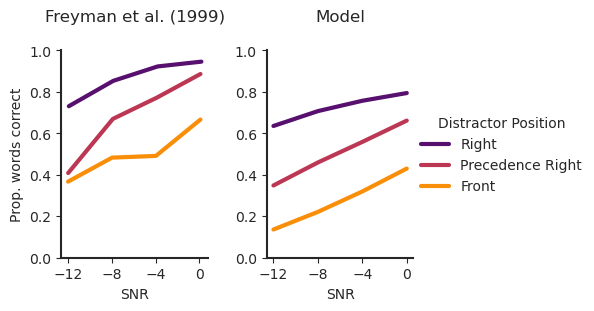

In [106]:
# hue_order = ['F-R', "F-FR", "F-RF", "FR-RF", "FR-FR", 'F-F']
hue_order = ['F-R',  "F-RF", 'F-F']

# rename dist_lead_channel names 
name_map = {'F-R':'Right', 'F-FR':'Precedence Front', 'F-RF':'Precedence Right', 'F-F':'Front', 'FR-RF':'Both simulated, right distractor', 'FR-FR':'Both simulated front'}
hue_order = [name_map[x] for x in hue_order]



sns.set_style('ticks')


# model_to_plot = freyman_grouped_results[(freyman_grouped_results.model == 'word_task_half_co_loc_v07')].copy()
model_to_plot = fba_total_summary.copy() #freyman_grouped_results[(freyman_grouped_results.model == 'word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout')].copy()
# model_to_plot.loc[model_to_plot.distractor_azim == 0, "distractor_azim"] = 60
# make dist location be abs 
# model_to_plot['distractor_azim'] = model_to_plot['distractor_azim'].abs()

# model_to_plot.loc[model_to_plot.snr == 'clean', 'snr'] = 6
# model_to_plot = model_to_plot[(model_to_plot.snr.isin([-12, -8, -4, 0])) & (model_to_plot.distractor_azim == 60)]
model_to_plot['model'] = 'Model'

# merge model_to_plot with human data
freyman_human_data['model'] = 'Freyman et al. (1999)'
freyman_human_data['dist_lead_channel'] = freyman_human_data['diotic_cond'] 
freyman_human_data['accuracy'] = freyman_human_data['accuracy']/100

data_to_plot = pd.concat([model_to_plot, freyman_human_data], axis=0)

data_to_plot['dist_lead_channel'] = data_to_plot['dist_lead_channel'].map(name_map)


g = sns.relplot(data=data_to_plot, x='snr', y='accuracy',
             col='model', col_order=['Freyman et al. (1999)', 'Model'],
            hue='dist_lead_channel', kind='line',
            palette='inferno',hue_order=hue_order,
            errorbar=('se'),
            height=3, linewidth=3, aspect=0.75, legend=True,
            facet_kws={'sharey': False, 'sharex': False}
)

g.set(yticks=np.arange(0,  1.1, .20), xticks=np.arange(-12,  1, 4))
# set titles
g.set_titles("{col_name}", size=12, y=1.1)
# set axis labels
g.set_axis_labels("SNR", "Prop. words correct")
# set legend title
g._legend.set_title("Distractor Position")
# add w space
g.fig.subplots_adjust(wspace=.4)

# add x and y ticks 


# move legend closer to plot
# g._legend.set_bbox_to_anchor([0.9, 0.5])
# thicken axis lines
for ax in g.axes.flat:
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)
# don't share y ticks
# plt.tight_layout()
outfig_dest = Path('ARO_2024/figures')
# plt.tight_layout()
# plt.savefig(outfig_dest/'freyman_plot.svg', transparent=True, bbox_inches='tight')

In [105]:
data_to_plot

,dist_lead_channel,snr,accuracy,accuracy_sem,confusions,confusions_sem,model,diotic_cond,accuracy_mean
0,Front,-12.000000,0.135995,0.006817,0.488910,0.018543,Model,NaN,NaN
1,Front,-8.000000,0.220955,0.008851,0.374384,0.016238,Model,NaN,NaN
2,Front,-4.000000,0.319462,0.008842,0.274187,0.012090,Model,NaN,NaN
3,Front,0.000000,0.429939,0.010420,0.179482,0.007544,Model,NaN,NaN
4,Right,-12.000000,0.635192,0.012396,0.002535,0.000472,Model,NaN,NaN
5,Right,-8.000000,0.706907,0.011082,0.001426,0.000354,Model,NaN,NaN
6,Right,-4.000000,0.756812,0.008999,0.000713,0.000252,Model,NaN,NaN
7,Right,0.000000,0.794043,0.007849,0.000554,0.000187,Model,NaN,NaN
8,Precedence Right,-12.000000,0.348361,0.012194,0.173004,0.014523,Model,NaN,NaN
9,Precedence Right,-8.000000,0.459261,0.014957,0.106464,0.009933,Model,NaN,NaN
